### Neural Style Transfer
Gatys et al. 2015.
https://arxiv.org/pdf/1508.06576

In [2]:
import jax
import torch
import jax.numpy as jnp
from torchvision import models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image

In [3]:
dtd_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

torch.Size([1, 3, 224, 224])


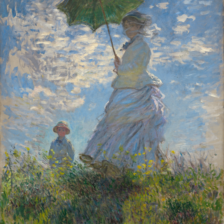

torch.Size([1, 3, 224, 224])


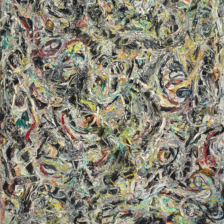

In [33]:
from pathlib import Path
from urllib.request import Request, urlopen

image_dir = Path("data/style_transfer")
image_dir.mkdir(parents=True, exist_ok=True)

urls = {
	"monet": "https://upload.wikimedia.org/wikipedia/commons/1/1b/Claude_Monet_-_Woman_with_a_Parasol_-_Madame_Monet_and_Her_Son_-_Google_Art_Project.jpg",
	"dali": "https://upload.wikimedia.org/wikipedia/commons/0/03/Adam_and_Eve_painting_by_Daniel_Heller.jpg",
	"picasso": "https://upload.wikimedia.org/wikipedia/commons/c/cb/La_mujer_que_llora_%28Femme_en_pleurs%29_de_Pablo_Picasso%2C_1937.jpg",
	"pollock": "https://upload.wikimedia.org/wikipedia/commons/4/44/76.2553.149_ph_web-1.jpg"
}

resized_images = {}

for name, url in urls.items():
	raw_path = image_dir / f"{name}.jpg"
	resized_path = image_dir / f"{name}_256.jpg"

	if not raw_path.exists():
		request = Request(
			url,
			headers={
				"User-Agent": "researchfarm-neural-style-transfer-notebook/1.0",
			},
		)

		with urlopen(request) as response, raw_path.open("wb") as f:
			f.write(response.read())


	img = Image.open(raw_path).convert("RGB")
	img_tens = dtd_transform(img)
	img = transforms.ToPILImage()(img_tens)
	img.save(resized_path)

	resized_images[name] = img_tens.unsqueeze(0)  # Add batch dimension

p = resized_images["monet"]
print(p.size())
display(transforms.ToPILImage()(p.squeeze(0).detach().cpu()))

a = resized_images["pollock"]
print(a.size())
display(transforms.ToPILImage()(a.squeeze(0).detach().cpu()))

In [34]:
p = resized_images["monet"]
p = p.requires_grad_(True)
optimizer = torch.optim.LBFGS([p], lr=1, max_iter=20)

In [8]:
from torchvision import models
torch.autograd.set_detect_anomaly(True, check_nan=False)
vgg19 = models.vgg19(pretrained=True)
vgg19.eval() # no dropout, no batchnorm, etc.

for param in vgg19.parameters():
	param.requires_grad = False # freeze the weights in every layer

for layer in vgg19.features:
    if isinstance(layer, torch.nn.Conv2d):
        layer.padding_mode = 'reflect'

/root/miniconda3/envs/notebooks/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/root/miniconda3/envs/notebooks/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
# helper
vgg19.features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode

In [10]:
conv_layers = [index for index, module in enumerate(vgg19.features) if isinstance(module, torch.nn.Conv2d)]
conv_layers

[0, 2, 5, 7, 10, 12, 14, 16, 19, 21, 23, 25, 28, 30, 32, 34]

In [23]:
# exploring different layers, keep diff layers here
A = {}
P = {}

In [24]:
# helper
def extract_features(y, Y, layers, detach=True):
	#input: y,
	#feature_map: Y
	#layer: up to layers
	def get_features_hook(l):
		def hook(model, input, output):
			Y[l] = output.detach() if detach else output
		return hook

	handles = []
	i = 0
	while i <= layers:
		target_layer = vgg19.features[conv_layers[i]]
		handles.append(target_layer.register_forward_hook(get_features_hook(conv_layers[i])))
		i += 1

	_ = vgg19(y)

	for hook_handle in handles:
		hook_handle.remove()

In [38]:
L = 5 # how many conv layers deep to use, 0-indexed
batches = 8
alpha = 1
gamma = 1e-2

# alpha/beta ratio controls mixing. i fucked up somewhere so this ratio is very off from the paper.

# extract features ONCE
# a -> A
extract_features(a, A, L)

# display(transforms.ToPILImage()(A[L].squeeze(0)[0].detach().cpu()))

def gram_matrix(feat):
	b, c, h, w = feat.shape
	feat_flat = feat.reshape(b, c, h * w)
	G = feat_flat @ feat_flat.transpose(1, 2)
	return G

for b in range(batches):

	def closure():
		optimizer.zero_grad()

		# p -> P
		extract_features(p, P, L, detach=False)

		# display the abstract features
		# last_layer = conv_layers[L]
		# content_loss = torch.nn.functional.mse_loss(A[last_layer], P[last_layer])

		i = 0
		style_loss = 0
		while i <= L:
			# G = F @ F.T
			# F = (1, 256, 56, 56)
			l = conv_layers[i]
			b, c, h, w = P[l].shape
			assert b == 1
			G = gram_matrix(P[l])
			A_ = gram_matrix(A[l])
			E_l = torch.sum((G - A_)**2) / (c * h * w)
			style_loss += E_l
			i += 1

		style_loss /= i

		tv_loss = torch.sum(torch.abs(p[:, :, :, :-1] - p[:, :, :, 1:])) + torch.sum(torch.abs(p[:, :, :-1, :] - p[:, :, 1:, :]))

		total_loss = alpha * style_loss + gamma * tv_loss
		total_loss.backward()
		return total_loss

	loss = optimizer.step(closure)
	if torch.isnan(loss):
		print("image range:", p.detach().min().item(), p.detach().max().item())
		break

	print(f"loss={loss.item():.8f}")


	# save image each batch
	# make sure to create the output directory if it doesn't exist
	output_dir = Path("output")
	output_dir.mkdir(parents=True, exist_ok=True)
	# torch.save(x, f"output/output_{b}.pt")
	transforms.ToPILImage()(p.squeeze(0).detach().cpu()).save(f"output/adaptive_{b+31}.png")

torch.save(p, f"output/adaptive_last.pt")
# content_loss mse loss ~ 0.001 in order to begin seeing details, where alpha=1

loss=2088.64624023
loss=111825067701366340555350818684928.00000000
image range: nan nan


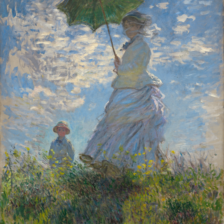

In [35]:
display(transforms.ToPILImage()(p.squeeze(0).detach().cpu()))

In [41]:
# stich into gif
from PIL import Image

images = [Image.open(img) for img in [f"output/adaptive_{i}.png" for i in range(0, 31)]]

# 3. Save as an animated GIF
# duration=200 means 200 milliseconds per frame (5 frames per second)
# loop=0 means the GIF will loop infinitely
images[0].save(
    'output/adaptive_output.gif',
    save_all=True,
    append_images=images[1:],
    duration=100, 
    loop=0
)

In [182]:
from IPython.display import Image, HTML, display
display(HTML('<img src="output/animated_output.gif" style="width: 30%; height: auto;">'))